In [1]:
import numpy as np
import xarray as xr

In [2]:
# JdF box, including cells to 50 m depth
ii1, ii2 = 300, 365
jj1, jj2 = 50, 100
km = 24

In [3]:
pp = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_month_climatology_prod_T_20070101_20231231.nc')

In [4]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

In [5]:
volume = mesh.tmask * mesh.e1t * mesh.e2t * mesh.e3t_0
denominator = np.nansum(
    np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [6]:
climate = pp.PPDIATNO3[6] + pp.PPPHYNO3[6]

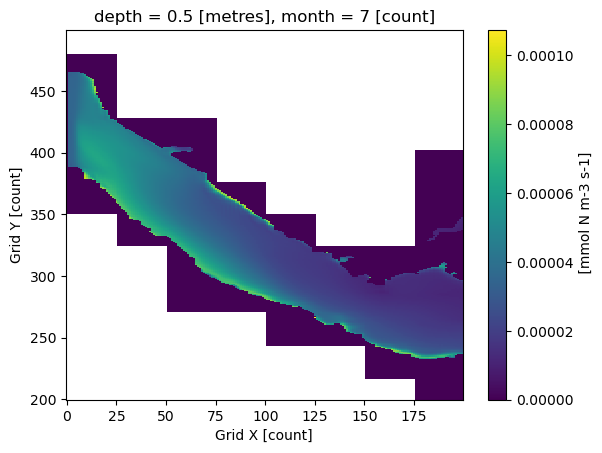

In [7]:
climate[0, 200:500, 0:200].plot();

In [8]:
numerator = np.nansum(
    np.array(climate[0:km, ii1:ii2, jj1:jj2]) * np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [9]:
climatology_average_productivity = numerator/denominator * 86400
climatology_average_productivity

np.float64(0.47491109924726205)

In [10]:
hw2014 = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20140701_20140731.nc')
hw2015 = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20150701_20150731.nc')
hw2016 = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20160701_20160731.nc')
hw2017 = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20170701_20170731.nc')

In [11]:
hw = (hw2014.PPDIATNO3[0] + hw2015.PPDIATNO3[0] + hw2016.PPDIATNO3[0] + hw2017.PPDIATNO3[0] +
      hw2014.PPPHYNO3[0] + hw2015.PPPHYNO3[0] + hw2016.PPPHYNO3[0] + hw2017.PPPHYNO3[0])/ 4.

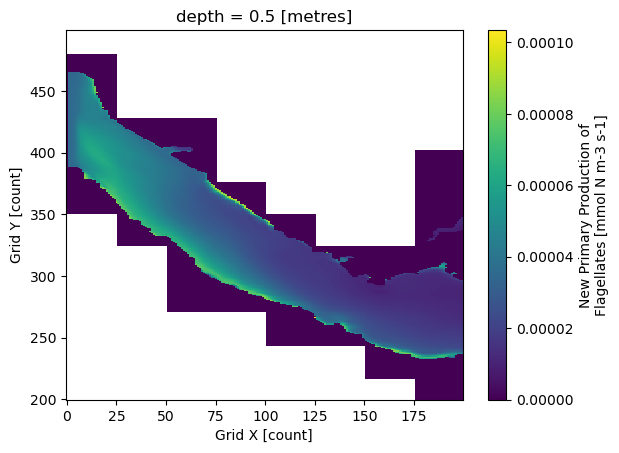

In [12]:
hw[0, 200:500, 0:200].plot();

In [14]:
numerator_hw = np.nansum(
    np.array(hw[0:km, ii1:ii2, jj1:jj2]) * np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [15]:
hw_average_productivity = numerator_hw/denominator * 86400
hw_average_productivity

np.float64(0.4499355837901554)

In [16]:
# Central part of JdF Strait about 60 km long
# Currents in July in upper JdF about 30 cm/s based on Thomson et al 2007 Fig 6
time = 60e3/0.3 / 86400 # in days
time

2.314814814814815

In [17]:
time * (hw_average_productivity - climatology_average_productivity)

np.float64(-0.05781369318774684)